# Week 7 Assignment

This week we are collecting some data from Reddit and doing some basic EDA on it. You should:

- create your Reddit account and API keys
- collect data from a subreddit of your choice
    - at a minimum, collect the posts from the subreddit; optionally collect comments on the posts
- save the data to a SQLite3 database
- perform some basic EDA on the data
    - create at least 2 plots
- write a short analysis at the end describing the process and results
- turn in the Jupyter Notebook and PDF printout or export to the week 7 dropbox

***Optional* advanced section**
- Practice SQL queries and select a subsection of the posts you collected
- Modify your code to collect data beyond the 1000 item limit
- Collect comments from the posts for analysis next week and do some EDA on the comments (e.g. who is the top commenter, which commenters have the most up and down votes or most controversial posts, etc)
- examine n-grams ([bigrams](https://stackoverflow.com/a/37651184/4549682), trigrams) or [collocations](https://www.geeksforgeeks.org/nlp-word-collocations/)

Note: There is no solution file for this week.

In [1]:
#!conda install -c conda-forge praw -y
#%pip install praw

In [2]:
#Importing our modules

import praw
import pandas as pd

import credentials

In [3]:
'''
Entering our reddit credentials from the credentials python file.
We then use the subreddit 'nba' as it is a subreddit I am familiar with.

We sort by hot as that is the default sorting option on reddit.
We could also come back and use a different sorting method to gather
new posts.
'''

reddit = praw.Reddit(client_id=credentials.client_id,
                     client_secret=credentials.client_secret,
                     user_agent=credentials.user_agent)

nba_subreddit = reddit.subreddit('nba').hot(limit=None)

In [4]:
'''
Here we enter each post (from the first 1000) of both the hot categroy
and then again with the top from the last year category (2000 total).  
We make sure that we don't duplicate posts as well.

We pass these values into a dictionary which we then convert to a 
dataframe in pandas to hold all of our data.

Some data points we get are the title of the post, the link to the 
post, the author of the post, the number of comments on the post,
what the post may have said in the description, and the "score".

We also then collected the first 5 comments from each post and stored
that data into a second dataframe.

***For the data analysis moving forward, I am going to only use 10 posts 
so that my computer can run everything quickly.  At the end, I will do
+1000 posts.
'''

reddit_data = {
    'post id': [], 'title': [], 'link': [], 'author': [],
    'n_comments': [], 'score': [], 'text': []
}

reddit_comments = {
    'post id': [],  # Add post_id to link comments to posts
    'author': [], 
    'comment': []
}
nba_subreddit = reddit.subreddit('nba').hot(limit=None)
nba_subreddit2 = reddit.subreddit('nba').top(time_filter = 'all', limit=None)

# Process first set of posts
for post in nba_subreddit:
    # Add post data
    reddit_data['post id'].append(post.id)
    reddit_data['title'].append(post.title)
    reddit_data['link'].append(post.permalink)
    if post.author is None:
        reddit_data['author'].append('')
    else:
        reddit_data['author'].append(post.author.name)
    
    reddit_data['n_comments'].append(post.num_comments)
    reddit_data['score'].append(post.score)
    reddit_data['text'].append(post.selftext)

    # Process comments - now with post_id to maintain relationship
    comments = post.comments.list()
    for comment in comments[0:5]: #Limit the amount of comments that we get to 5 for processing simplicity
        if comment.author is None:
            reddit_comments['author'].append('')
        else:
            reddit_comments['author'].append(comment.author.name)
        reddit_comments['comment'].append(comment.body)
        reddit_comments['post id'].append(post.id) 
            
# Process second set of posts, all parts are the same
for post in list(nba_subreddit2): 
    if post in nba_subreddit:
        pass
    else:
        reddit_data['post id'].append(post.id)
        reddit_data['title'].append(post.title)
        reddit_data['link'].append(post.permalink)
        if post.author is None:
            reddit_data['author'].append('')
        else:
            reddit_data['author'].append(post.author.name)
        
        reddit_data['n_comments'].append(post.num_comments)
        reddit_data['score'].append(post.score)
        reddit_data['text'].append(post.selftext)

        comments = post.comments.list()
        for comment in comments[0:5]:
            if comment.author is None:
                reddit_comments['author'].append('')
            else:
                reddit_comments['author'].append(comment.author.name)
            reddit_comments['comment'].append(comment.body)
            reddit_comments['post id'].append(post.id)

# Create separate DataFrames for posts and comments
nba_df = pd.DataFrame(reddit_data)
nba_comment = pd.DataFrame(reddit_comments)
nba_df

,post id,title,link,author,n_comments,score,text
0,1o6msn4,Daily Discussion Thread + Game Thread Index,/r/nba/comments/1o6msn4/daily_discussion_threa...,NBA_MOD,1,2,"# Game Threads Index (October 14, 2025):\n\n|T..."
1,1o6cdbe,[SERIOUS NEXT DAY THREAD] Post-Game Discussion...,/r/nba/comments/1o6cdbe/serious_next_day_threa...,NBA_MOD,6,7,"Here is a place to have in depth, x's and o's,..."
2,1o6peb2,The Celtics coaches just played a pickup game ...,/r/nba/comments/1o6peb2/the_celtics_coaches_ju...,Brady331,144,2439,video via Taylor Snow\n\nMore context via Noa ...
3,1o6o619,Joe Mazzulla does not like the NBA preseason: ...,/r/nba/comments/1o6o619/joe_mazzulla_does_not_...,Mission_Pay_3373,293,2329,
4,1o6met7,Giannis Antetokounmpo says he wants to finish ...,/r/nba/comments/1o6met7/giannis_antetokounmpo_...,Pickleskennedy1,195,1652,https://bleacherreport.com/articles/25260547-g...
...,...,...,...,...,...,...,...
1244,8vnrvy,[Charania] Free agent DeMarcus Cousins has agr...,/r/nba/comments/8vnrvy/charania_free_agent_dem...,HornyHindu,14062,30407,
1245,690ejg,Brandon Roy shot in leg while shielding childr...,/r/nba/comments/690ejg/brandon_roy_shot_in_leg...,theb3arjevv,1154,30401,
1246,1hyepof,Lakers coach JJ Redick with a lot of perspecti...,/r/nba/comments/1hyepof/lakers_coach_jj_redick...,YujiDomainExpansion,1742,30338,
1247,bt37ig,[Post Game Thread] The Toronto Raptors (4-2) d...,/r/nba/comments/bt37ig/post_game_thread_the_to...,nick168,7642,30270,**[](/MIL) MIL**|**Min**|**FG**|**FT**|**3PT**...


In [5]:
nba_comment

,post id,author,comment
0,1o6msn4,NBA_MOD,\n\n# Top Highlights:\n\n0. [[Highlight] Victo...
1,1o6cdbe,AutoModerator,REMINDER: This thread is only for serious and ...
2,1o6cdbe,NBA_MOD,\n\n**Heat @ Hawks**\n\n[](/MIA) **118 - 119*...
3,1o6cdbe,NBA_MOD,\n\n**Spurs @ Pacers**\n\n[](/SAS) **124 - 10...
4,1o6cdbe,NBA_MOD,\n\n**Wizards @ Knicks**\n\n[](/WAS) **120 - ...
...,...,...,...
6008,g00h09,Cacanator,The steal and dunk has been his signature for ...
6009,g00h09,never_nude_,"This is such a lame ""six degrees"" story; but f..."
6010,g00h09,,Insane how big his hands are. I am 6 foot 7 an...
6011,g00h09,SirCharles54,That ref smiling made this clip


In [6]:
'''
Then we import our dataframe into a SQL using SQLite3.
We can check to see if the SQL was saved properly before closing 
the database.
As we can see, the data saved correctly!
'''

import sqlite3

nba = sqlite3.connect("nba_reddit.sqlite")
nba_com = sqlite3.connect("nba_reddit_comments.sqlite")
nba_df.to_sql('posts', nba, if_exists='replace', index=False)
nba_comment.to_sql('posts', nba_com, if_exists='replace', index=False)

nba_df_check = pd.read_sql_query('SELECT * FROM posts;', nba)
nba_com_df_check = pd.read_sql_query('SELECT * FROM posts;', nba_com)
nba.close()
nba_com.close()
nba_df_check

,post id,title,link,author,n_comments,score,text
0,1o6msn4,Daily Discussion Thread + Game Thread Index,/r/nba/comments/1o6msn4/daily_discussion_threa...,NBA_MOD,1,2,"# Game Threads Index (October 14, 2025):\n\n|T..."
1,1o6cdbe,[SERIOUS NEXT DAY THREAD] Post-Game Discussion...,/r/nba/comments/1o6cdbe/serious_next_day_threa...,NBA_MOD,6,7,"Here is a place to have in depth, x's and o's,..."
2,1o6peb2,The Celtics coaches just played a pickup game ...,/r/nba/comments/1o6peb2/the_celtics_coaches_ju...,Brady331,144,2439,video via Taylor Snow\n\nMore context via Noa ...
3,1o6o619,Joe Mazzulla does not like the NBA preseason: ...,/r/nba/comments/1o6o619/joe_mazzulla_does_not_...,Mission_Pay_3373,293,2329,
4,1o6met7,Giannis Antetokounmpo says he wants to finish ...,/r/nba/comments/1o6met7/giannis_antetokounmpo_...,Pickleskennedy1,195,1652,https://bleacherreport.com/articles/25260547-g...
...,...,...,...,...,...,...,...
1244,8vnrvy,[Charania] Free agent DeMarcus Cousins has agr...,/r/nba/comments/8vnrvy/charania_free_agent_dem...,HornyHindu,14062,30407,
1245,690ejg,Brandon Roy shot in leg while shielding childr...,/r/nba/comments/690ejg/brandon_roy_shot_in_leg...,theb3arjevv,1154,30401,
1246,1hyepof,Lakers coach JJ Redick with a lot of perspecti...,/r/nba/comments/1hyepof/lakers_coach_jj_redick...,YujiDomainExpansion,1742,30338,
1247,bt37ig,[Post Game Thread] The Toronto Raptors (4-2) d...,/r/nba/comments/bt37ig/post_game_thread_the_to...,nick168,7642,30270,**[](/MIL) MIL**|**Min**|**FG**|**FT**|**3PT**...


In [7]:
nba_com_df_check

,post id,author,comment
0,1o6msn4,NBA_MOD,\n\n# Top Highlights:\n\n0. [[Highlight] Victo...
1,1o6cdbe,AutoModerator,REMINDER: This thread is only for serious and ...
2,1o6cdbe,NBA_MOD,\n\n**Heat @ Hawks**\n\n[](/MIA) **118 - 119*...
3,1o6cdbe,NBA_MOD,\n\n**Spurs @ Pacers**\n\n[](/SAS) **124 - 10...
4,1o6cdbe,NBA_MOD,\n\n**Wizards @ Knicks**\n\n[](/WAS) **120 - ...
...,...,...,...
6008,g00h09,Cacanator,The steal and dunk has been his signature for ...
6009,g00h09,never_nude_,"This is such a lame ""six degrees"" story; but f..."
6010,g00h09,,Insane how big his hands are. I am 6 foot 7 an...
6011,g00h09,SirCharles54,That ref smiling made this clip


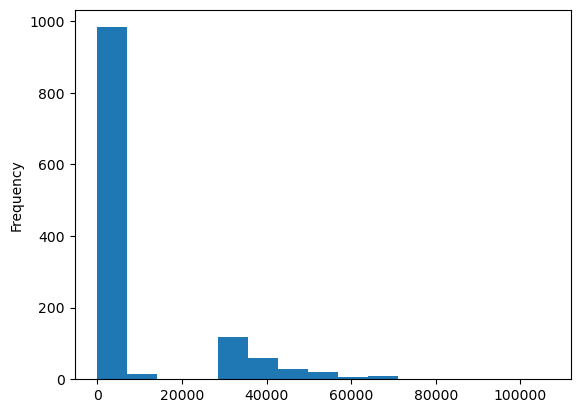

In [8]:
'''
Here is a graph of the distribution of the "score" of all the posts.  We
can see that the graph is extremely right skewed and that posts get pretty
high scores here, which is expected from a subreddit with millions
of users.
'''

_ = nba_df['score'].plot.hist(bins=15)

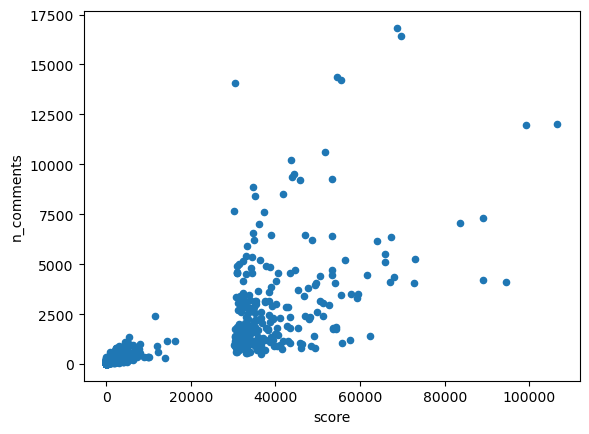

In [9]:
'''
Below is a scatter plot of the posts with the "score" on the x-
axis and the number of comments on the y-axis.  We see that
there is a slight linear relationship between the two, which
again makes sense.
'''

_ = nba_df.plot.scatter(x='score', y='n_comments')

In [10]:
'''
Using querys to get posts that have more than 10k score.
'''

nba = sqlite3.connect("nba_reddit.sqlite")
nba_posts = pd.read_sql_query('SELECT * FROM posts WHERE score>10000', nba)
nba.close()
nba_posts

,post id,title,link,author,n_comments,score,text
0,1o4261l,[Paolo Banchero] after a fan asks him to score...,/r/nba/comments/1o4261l/paolo_banchero_after_a...,AashyLarry,1124,16367,
1,1o3kkci,WNBA Finals MVP A'ja Wilson to Miami Heat star...,/r/nba/comments/1o3kkci/wnba_finals_mvp_aja_wi...,Goosedukee,611,12148,
2,1o1st5f,KD to Ace Bailey: “You’re new here. You brand ...,/r/nba/comments/1o1st5f/kd_to_ace_bailey_youre...,Proof-Umpire-7718,366,10137,\n
3,1ny9nmo,Year 3 Wembanyama…,/r/nba/comments/1ny9nmo/year_3_wembanyama/,No_Refrigerator6996,1160,14275,
4,1nuxqrx,Warriors rookies want to take a picture with S...,/r/nba/comments/1nuxqrx/warriors_rookies_want_...,sriracha82,302,13933,
...,...,...,...,...,...,...,...
252,8vnrvy,[Charania] Free agent DeMarcus Cousins has agr...,/r/nba/comments/8vnrvy/charania_free_agent_dem...,HornyHindu,14062,30407,
253,690ejg,Brandon Roy shot in leg while shielding childr...,/r/nba/comments/690ejg/brandon_roy_shot_in_leg...,theb3arjevv,1154,30401,
254,1hyepof,Lakers coach JJ Redick with a lot of perspecti...,/r/nba/comments/1hyepof/lakers_coach_jj_redick...,YujiDomainExpansion,1742,30338,
255,bt37ig,[Post Game Thread] The Toronto Raptors (4-2) d...,/r/nba/comments/bt37ig/post_game_thread_the_to...,nick168,7642,30270,**[](/MIL) MIL**|**Min**|**FG**|**FT**|**3PT**...


In [11]:
'''
Using querys to get the posts that have over 1K comments
'''

nba = sqlite3.connect("nba_reddit.sqlite")
nba_today = pd.read_sql_query('SELECT * FROM posts WHERE n_comments>1000', nba)
nba.close()
nba_today

,post id,title,link,author,n_comments,score,text
0,1o4261l,[Paolo Banchero] after a fan asks him to score...,/r/nba/comments/1o4261l/paolo_banchero_after_a...,AashyLarry,1124,16367,
1,1o0tysk,[ESPN] Richard Jefferson reveals that players ...,/r/nba/comments/1o0tysk/espn_richard_jefferson...,YujiDomainExpansion,1118,4459,
2,1nzq7qp,LeBron James: The decision of all decisions. O...,/r/nba/comments/1nzq7qp/lebron_james_the_decis...,Turbostrider27,1366,5323,
3,1ny9nmo,Year 3 Wembanyama…,/r/nba/comments/1ny9nmo/year_3_wembanyama/,No_Refrigerator6996,1160,14275,
4,1ntbwaq,Devin Booker just gave IShowSpeed a tour of hi...,/r/nba/comments/1ntbwaq/devin_booker_just_gave...,IgotgAme_k,2399,11463,
...,...,...,...,...,...,...,...
218,q69w4u,Michael Jordan if he's concerned about the COV...,/r/nba/comments/q69w4u/michael_jordan_if_hes_c...,urfaselol,1416,30491,
219,8vnrvy,[Charania] Free agent DeMarcus Cousins has agr...,/r/nba/comments/8vnrvy/charania_free_agent_dem...,HornyHindu,14062,30407,
220,690ejg,Brandon Roy shot in leg while shielding childr...,/r/nba/comments/690ejg/brandon_roy_shot_in_leg...,theb3arjevv,1154,30401,
221,1hyepof,Lakers coach JJ Redick with a lot of perspecti...,/r/nba/comments/1hyepof/lakers_coach_jj_redick...,YujiDomainExpansion,1742,30338,


In [12]:
'''
Another thing we could do is find who posts the most

These results make sense.  A mod will post a lot since it is a collection 
of people who run and maintain promotional stuff and important game
threads.  MrBuckBuck being the top poster also makes sense (he is very
famous on the subreddit.  Dude posts like clockwork.)
'''

nba = sqlite3.connect("nba_reddit.sqlite")
nba_commenter = pd.read_sql_query('SELECT author, COUNT(*) as posts_count FROM posts GROUP BY author ORDER BY posts_count DESC', nba)
nba.close()
nba_commenter

,author,posts_count
0,MrBuckBuck,153
1,NBA_MOD,64
2,TheRealPdGaming,52
3,AashyLarry,34
4,Ilikesporks_,30
...,...,...
470,3PointTendency,1
471,31WTexaco,1
472,2005Spurs,1
473,12footjumpshot,1


In [13]:
'''
Let's try to find the person who comments the most.

We select the sql database with all of our comments stored and count
the unique values in the author table to find who comments the most
among all the posts we have collected.
'''

nba_comment = sqlite3.connect("nba_reddit_comments.sqlite")
nba_com_most = pd.read_sql_query('SELECT author, COUNT(*) as n_comments FROM posts GROUP BY author ORDER BY n_comments DESC', nba_comment)
nba_comment.close()
nba_com_most

,author,n_comments
0,AutoModerator,277
1,,247
2,heat_fan_,152
3,NBA_MOD,81
4,Jack_The_Sparrow_,26
...,...,...
3607,-HeisenBird-,1
3608,-GrapeGrass-,1
3609,-Gab-,1
3610,-EstebanJR-,1


In [14]:
'''
Now let's do some n-gram analysis with nltk package
First, let's look at the most common words in a post's title.
'''

#!conda install -c conda-forge nltk -y
#nltk.download('stopwords')
import nltk
from nltk.corpus import stopwords

stops = stopwords.words('english')
words = ' '.join (nba_df['title']).lower().split()
cleaned_words = [w for w in words if w not in set(stops)]
fd = nltk.FreqDist(cleaned_words)
fd.most_common(20)

[('[highlight]', 251),
 ('game', 171),
 ('nba', 152),
 ('-', 87),
 ('lebron', 63),
 ('3', 62),
 ('thread]', 57),
 ('2025)', 57),
 ('(october', 55),
 ('team', 55),
 ('first', 52),
 ('(with', 49),
 ('|', 48),
 ('players', 48),
 ('[highlights]', 46),
 ('like', 45),
 ('lakers', 45),
 ('defeat', 43),
 ('(0-0)', 43),
 ('new', 43)]

<Axes: xlabel='Samples', ylabel='Counts'>

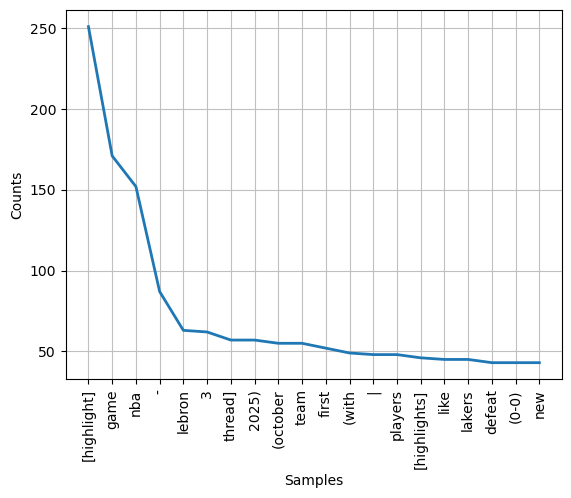

In [15]:
fd.plot(20)

In [16]:
'''
We can also look at some of the most common bigrams
'''

bigram = nltk.FreqDist(nltk.bigrams(cleaned_words))
bigram.most_common(20)

[(('game', 'thread:'), 43),
 (('-', '(october'), 43),
 (('[post', 'game'), 42),
 (('game', 'thread]'), 42),
 (('lebron', 'james'), 25),
 (('los', 'angeles'), 24),
 (('(with', 'replays)'), 22),
 (('cooper', 'flagg'), 19),
 (('luka', 'doncic'), 16),
 (('(0-0)', '-'), 16),
 (('next', 'day'), 15),
 (('angeles', 'lakers'), 15),
 (('(0-0)', '@'), 15),
 (('daily', 'discussion'), 14),
 (('discussion', 'thread'), 14),
 (('thread', '+'), 14),
 (('+', 'game'), 14),
 (('game', 'thread'), 14),
 (('thread', 'index'), 14),
 (('[serious', 'next'), 14)]

<Axes: xlabel='Samples', ylabel='Counts'>

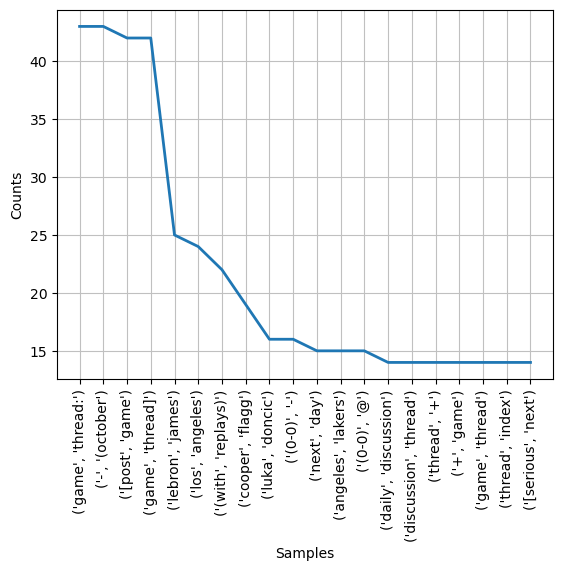

In [17]:
bigram.plot(20)

# Analysis

For this week, we looked at data from posts in a subreddit of our choice and saved it to a SQL database so that we could perform some basic EDAs on the subreddit.  I choose the subreddit "nba" since I'm a big basketball fan and I'm on that subreddit almost every day.  

First, we had to create a reddit API and read in the credentials.  Next, we loaded in the nba subreddit and accessed the first 1000 posts sorted by hot and then any additional posts under the filtering of top posts all time.  Next, we moved the posts into a dataframe to store them and then saved this dataframe to a SQLite database.  Now we have access to these posts and all of their data through the database, which makes perfomring EDA on it very easy.

The next two graphs show the distribution of upvotes that a post got and then looked at a scatter plot showing the relationship between upvotes and comments.  The distribution of upvotes is very right skewed.  The scatter plot shows a positive linear relationship between upvotes and comments, which makes sense.  More upvotes means more people who see the post.  We also looked at posts with more than 10k score and posts with more than 1k comments, of which there were about 200 for each.

We looked at who posts the most and found MrBuckBuck and MODs as the two highest, with 153 and 64 posts respectively.  The person who comments the most that is not an AI MOD is heat_fan_ with 152 comments.  Finally, we did some n-gram analysis, looking at the words that appeared the most in posts, both single words and bigrams.  The results made a lot of sense, especially once we took out common english words with nltk stopwords, getting words like "highlight", "game", or "lebron", and "Game thread", "post game", or "luka doncic" for the bigrams.  All the most common words are associated with basketball as we might expect.

Some further analysis can be done with this SQLite database.  We can also continue to feed in new data each time we run the code, and update our results from there.  We could continously update the sql database with the "hot" posts of the day.  We could also do more word analysis to find which player is talked about the most.  We could even collect controversial posts and see which players are most associated with these posts as well.  Collecting 1000s of posts along with their comments gives us many meaningful insights to the subreddit of r_nba.